# 02 - Visualizations
**QSS 20 Final Project | Olivia Tak**

**Research Question:** Does the emotional tone and arousal of YouTube trending video titles predict their virality?

This notebook generates all figures for the project. Figures are saved to `../output/` as .png files.

**Inputs:** `../data/df_2023_sentiment.csv`  
**Outputs:**
- `fig1_arousal_distribution.png`
- `fig2_arousal_vs_views.png`
- `fig3_views_by_sentiment.png`
- `fig4_boxplot_views_by_sentiment.png`
- `fig5_views_by_category.png`
- `fig6_arousal_by_category.png`
- `fig7_sentiment_composition_by_category.png`
- `fig8_heatmap_category_sentiment.png`
- `fig9_views_by_category_sentiment.png`
- `fig10_top_trending.png`

## Imports

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Helper functions and constants

In [2]:
# consistent color mapping for sentiment labels used across all figures
SENTIMENT_COLORS = {
    'positive': 'palegreen',
    'negative': 'lightcoral',
    'neutral':  'khaki'
}


def save_fig(filename, caption):
    """Save the current matplotlib figure to ../output/ and print its caption.

    Parameters
    ----------
    filename : str, e.g. 'fig2_arousal_vs_views.png'
    caption  : str, full figure caption for the paper
    """
    plt.tight_layout()
    plt.savefig(f'../output/{filename}', dpi=150)
    plt.show()
    print(f'Caption: {caption}')

## Load sentiment data

In [3]:
df = pd.read_csv('../data/df_2023_sentiment.csv')
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

Loaded: 12,176 rows, 26 columns


## Figure 1: Distribution of arousal scores

Shows how emotional intensity is distributed across all 12,176 trending videos. The spike at zero is important context: many titles score exactly 0 because VADER detects no sentiment-bearing words (e.g. '2024 iPhone Review', 'NFL Week 12 Highlights'). These are neutral by VADER's measure but not necessarily emotionally moderate.

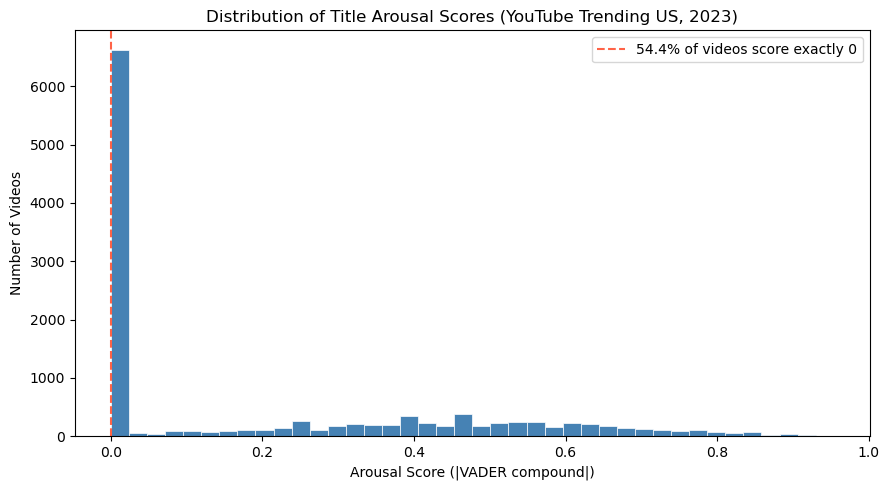

Caption: Histogram of VADER arousal scores for 12,176 unique YouTube trending videos (US, 2023). 54.4% of titles score exactly 0, meaning VADER detected no sentiment-bearing words. This reflects the descriptive, keyword-heavy nature of many YouTube titles rather than true emotional neutrality, and is an important limitation of the VADER approach.


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    df['arousal_score'],
    bins=40,
    color='steelblue',
    edgecolor='white',
    linewidth=0.5
)

zero_pct = (df['arousal_score'] == 0).mean() * 100
ax.axvline(0, color='tomato', linewidth=1.5, linestyle='--', label=f'{zero_pct:.1f}% of videos score exactly 0')

ax.set_xlabel('Arousal Score (|VADER compound|)')
ax.set_ylabel('Number of Videos')
ax.set_title('Distribution of Title Arousal Scores (YouTube Trending US, 2023)')
ax.legend()

save_fig(
    'fig1_arousal_distribution.png',
    f'Histogram of VADER arousal scores for {len(df):,} unique YouTube trending videos (US, 2023). '
    f'{zero_pct:.1f}% of titles score exactly 0, meaning VADER detected no sentiment-bearing words. '
    'This reflects the descriptive, keyword-heavy nature of many YouTube titles '
    'rather than true emotional neutrality, and is an important limitation of the VADER approach.'
)

## Figure 2: Arousal score vs. log views

Scatter plot showing the relationship between title emotional intensity and video virality, colored by sentiment label. This is the core visual for the research question.

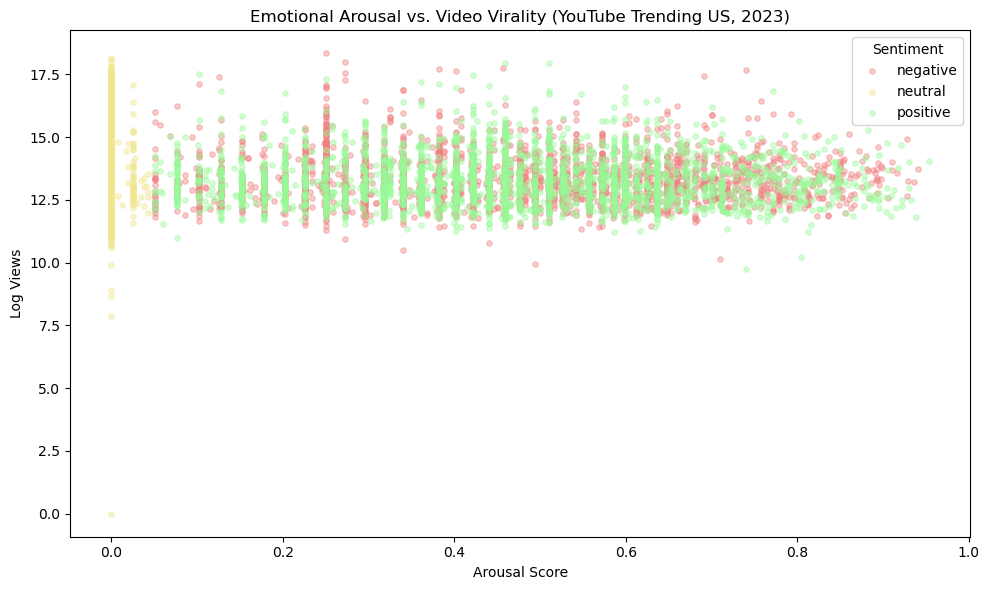

Caption: Scatter plot of arousal score versus log views for 12,176 unique YouTube trending videos (US, 2023), colored by sentiment label. Points cluster near zero arousal, reflecting that the majority of trending titles are classified as neutral. The flat distribution suggests no strong positive relationship between emotional intensity and virality.


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, group in df.groupby('sentiment_label'):
    ax.scatter(
        group['arousal_score'],
        group['log_views'],
        c=SENTIMENT_COLORS[label],
        label=label,
        alpha=0.4,
        s=15
    )

ax.set_xlabel('Arousal Score')
ax.set_ylabel('Log Views')
ax.set_title('Emotional Arousal vs. Video Virality (YouTube Trending US, 2023)')
ax.legend(title='Sentiment')

save_fig(
    'fig2_arousal_vs_views.png',
    'Scatter plot of arousal score versus log views for 12,176 unique YouTube trending videos '
    '(US, 2023), colored by sentiment label. Points cluster near zero arousal, reflecting that '
    'the majority of trending titles are classified as neutral. The flat distribution suggests '
    'no strong positive relationship between emotional intensity and virality.'
)

## Figure 3: Average view count by sentiment label

Direct comparison of mean view counts across sentiment groups — the central descriptive result of the analysis.

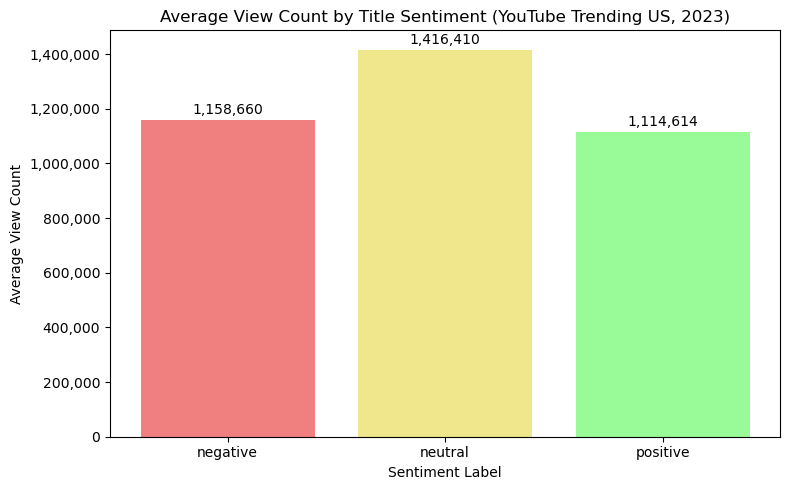

Caption: Average view count by title sentiment label for 12,176 unique YouTube trending videos (US, 2023). Neutral-titled videos average 1,416,410 views, outperforming both negative (1,158,660) and positive (1,114,614) titles. The difference between neutral and non-neutral groups is statistically significant (t = 5.45, p < 0.001).


In [6]:
# order: negative, neutral, positive for visual clarity
sentiment_order = ['negative', 'neutral', 'positive']
sentiment_views = (
    df.groupby('sentiment_label')['view_count']
      .mean()
      .reindex(sentiment_order)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    sentiment_views.index,
    sentiment_views.values,
    color=[SENTIMENT_COLORS[s] for s in sentiment_order]
)

ax.set_xlabel('Sentiment Label')
ax.set_ylabel('Average View Count')
ax.set_title('Average View Count by Title Sentiment (YouTube Trending US, 2023)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# value labels on top of each bar
for bar, val in zip(bars, sentiment_views.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10000,
        f'{val:,.0f}',
        ha='center', va='bottom', fontsize=10
    )

save_fig(
    'fig3_views_by_sentiment.png',
    'Average view count by title sentiment label for 12,176 unique YouTube trending videos '
    '(US, 2023). Neutral-titled videos average 1,416,410 views, outperforming both negative '
    '(1,158,660) and positive (1,114,614) titles. '
    'The difference between neutral and non-neutral groups is statistically significant '
    '(t = 5.45, p < 0.001).'
)

## Figure 4: Distribution of log views by sentiment label

Boxplot showing the full distribution of log views per sentiment group, not just the mean. Complements Figure 5 and directly visualizes what the t-tests are testing.

/var/folders/g7/x_kff6s90qd9g_sh7cp9r4100000gn/T/ipykernel_27930/2590653306.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


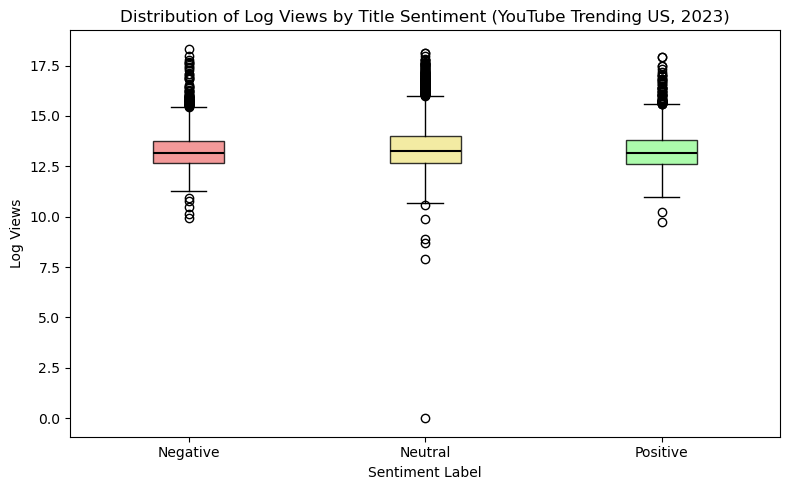

Caption: Boxplot of log-transformed view counts by title sentiment label. Boxes show the interquartile range (25th-75th percentile); horizontal lines show the median; whiskers extend to 1.5x IQR. Neutral titles show a higher median and tighter upper distribution compared to positive and negative titles.


In [7]:
sentiment_order = ['negative', 'neutral', 'positive']
data = [df[df['sentiment_label'] == s]['log_views'].values for s in sentiment_order]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    data,
    labels=[s.capitalize() for s in sentiment_order],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5)
)
for patch, s in zip(bp['boxes'], sentiment_order):
    patch.set_facecolor(SENTIMENT_COLORS[s])
    patch.set_alpha(0.8)

ax.set_xlabel('Sentiment Label')
ax.set_ylabel('Log Views')
ax.set_title('Distribution of Log Views by Title Sentiment (YouTube Trending US, 2023)')

save_fig(
    'fig4_boxplot_views_by_sentiment.png',
    'Boxplot of log-transformed view counts by title sentiment label. '
    'Boxes show the interquartile range (25th-75th percentile); '
    'horizontal lines show the median; whiskers extend to 1.5x IQR. '
    'Neutral titles show a higher median and tighter upper distribution '
    'compared to positive and negative titles.'
)

## Figure 5: Average view count by category

Shows which content categories attract the most views on average — important context for interpreting whether category (rather than sentiment) drives virality.

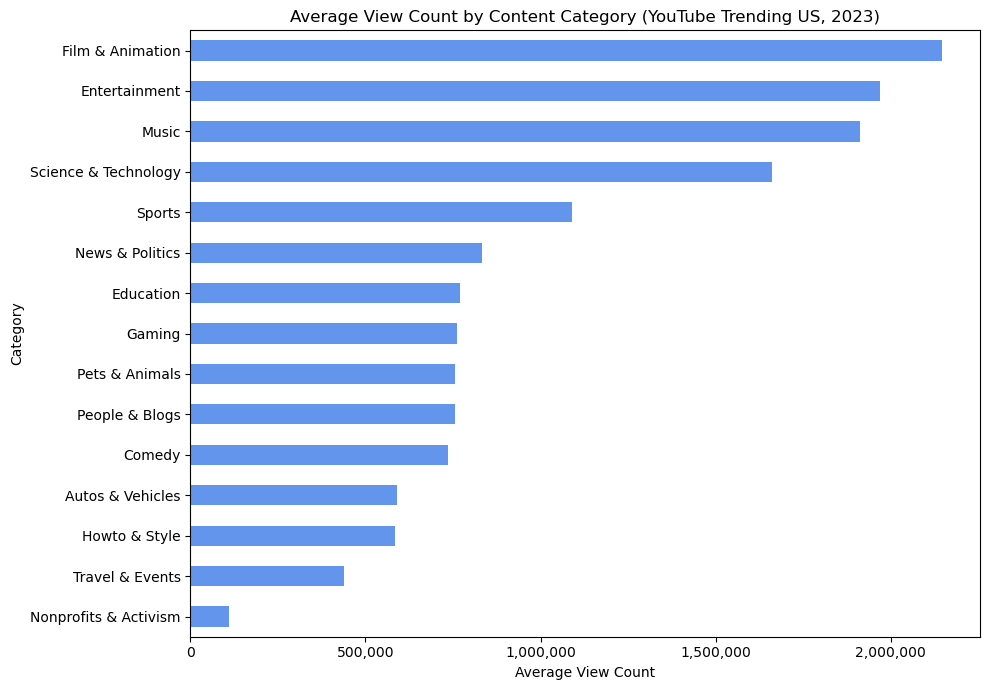

Caption: Average view count by content category among YouTube trending videos (US, 2023). Film & Animation and Music generate the highest average views; Travel & Events and Howto & Style the lowest. Category is a stronger predictor of virality than title sentiment.


In [8]:
category_views = (
    df.groupby('category')['view_count']
      .mean()
      .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
category_views.plot(kind='barh', ax=ax, color='cornflowerblue')

ax.set_xlabel('Average View Count')
ax.set_ylabel('Category')
ax.set_title('Average View Count by Content Category (YouTube Trending US, 2023)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

save_fig(
    'fig5_views_by_category.png',
    'Average view count by content category among YouTube trending videos (US, 2023). '
    'Film & Animation and Music generate the highest average views; '
    'Travel & Events and Howto & Style the lowest. '
    'Category is a stronger predictor of virality than title sentiment.'
)

## Figure 6: Average arousal score by category

Shows whether certain categories systematically use more emotional language in titles — relevant for interpreting whether the neutral-wins finding is confounded by category composition.

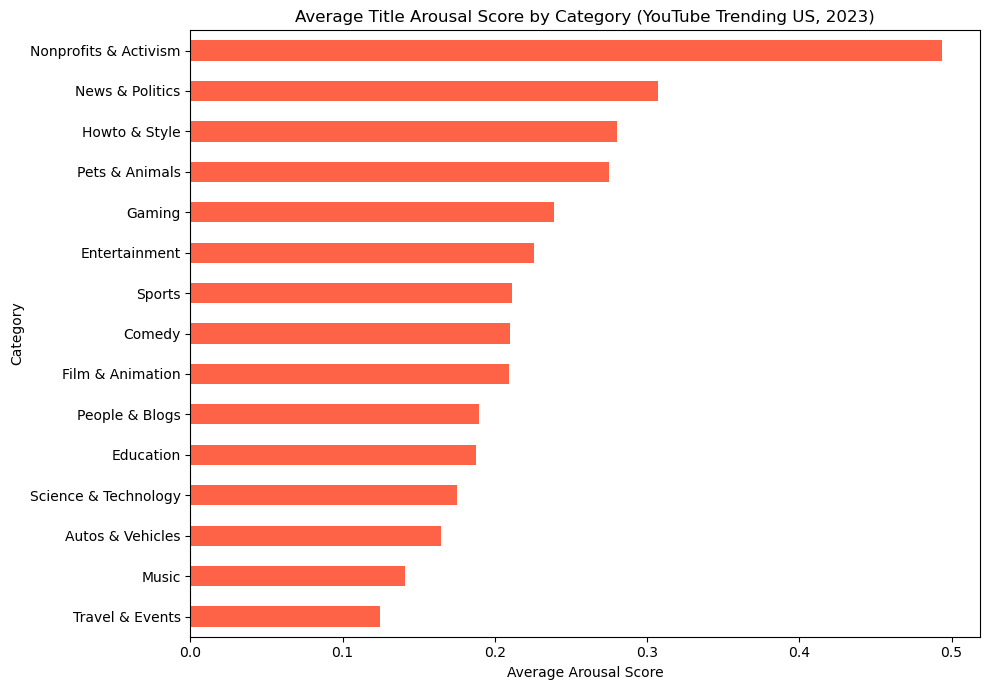

Caption: Average VADER arousal score by content category. News & Politics videos tend to have the most emotionally charged titles; Gaming and Music the least. Variation in arousal across categories suggests category composition may partially explain differences in observed virality by sentiment group.


In [9]:
category_arousal = (
    df.groupby('category')['arousal_score']
      .mean()
      .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
category_arousal.plot(kind='barh', ax=ax, color='tomato')

ax.set_xlabel('Average Arousal Score')
ax.set_ylabel('Category')
ax.set_title('Average Title Arousal Score by Category (YouTube Trending US, 2023)')

save_fig(
    'fig6_arousal_by_category.png',
    'Average VADER arousal score by content category. '
    'News & Politics videos tend to have the most emotionally charged titles; '
    'Gaming and Music the least. '
    'Variation in arousal across categories suggests category composition may partially '
    'explain differences in observed virality by sentiment group.'
)

## Figure 7: Sentiment composition by category

Shows what proportion of titles in each category are neutral, positive, or negative. Addresses whether neutral titles dominate only in certain high-view categories, which would confound the main finding.

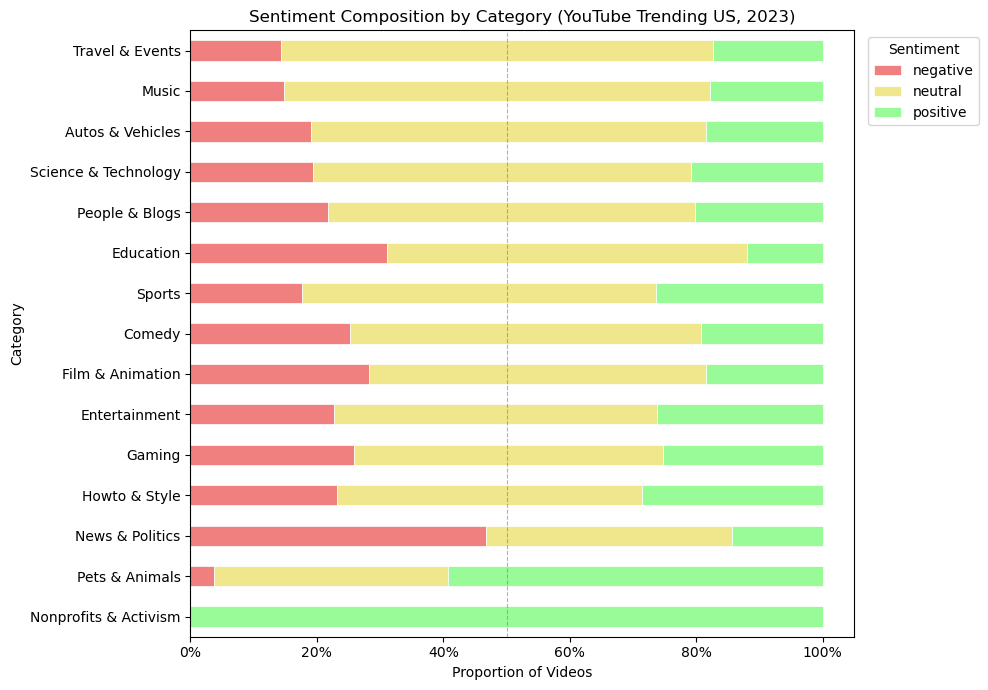

Caption: Stacked bar chart showing the proportion of neutral, positive, and negative titles within each content category, sorted by neutral proportion (ascending). Neutral titles are the majority in most categories, suggesting that the neutral advantage in virality is not driven solely by composition effects in a few categories.


In [10]:
# proportion of each sentiment within each category
cat_sent_prop = (
    df.groupby(['category', 'sentiment_label'])
      .size()
      .unstack(fill_value=0)[['negative', 'neutral', 'positive']]
      .div(df.groupby('category').size(), axis=0)
      .sort_values('neutral', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
cat_sent_prop.plot(
    kind='barh',
    stacked=True,
    color=[SENTIMENT_COLORS[s] for s in ['negative', 'neutral', 'positive']],
    ax=ax,
    edgecolor='white',
    linewidth=0.5
)

ax.set_xlabel('Proportion of Videos')
ax.set_ylabel('Category')
ax.set_title('Sentiment Composition by Category (YouTube Trending US, 2023)')
ax.legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.axvline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

save_fig(
    'fig7_sentiment_composition_by_category.png',
    'Stacked bar chart showing the proportion of neutral, positive, and negative titles '
    'within each content category, sorted by neutral proportion (ascending). '
    'Neutral titles are the majority in most categories, suggesting that the neutral '
    'advantage in virality is not driven solely by composition effects in a few categories.'
)

## Figure 8: Heatmap of log views by category and sentiment

Tests whether the neutral-wins pattern holds within individual content categories, or whether it is driven purely by category composition.

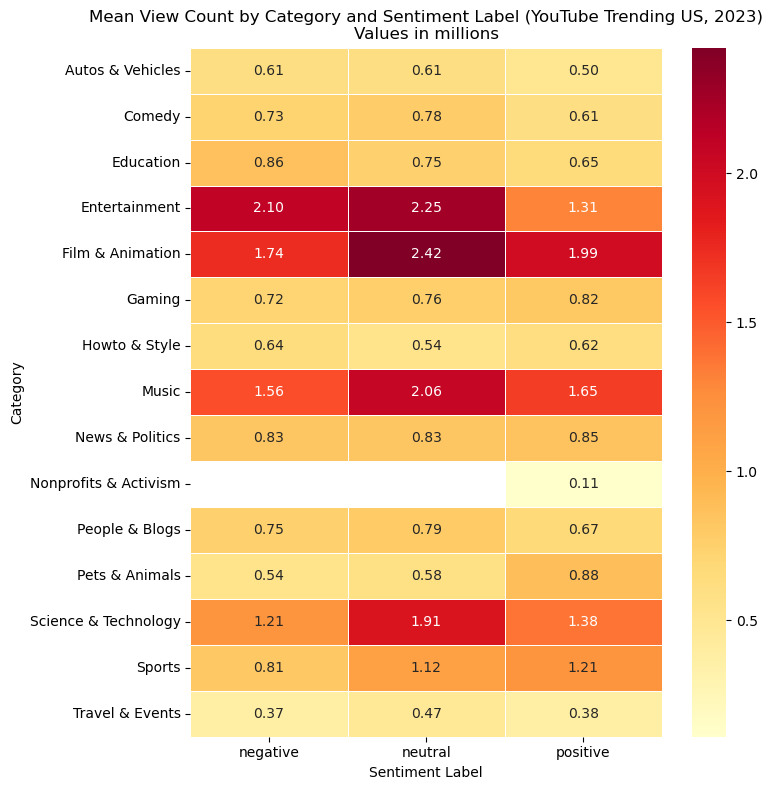

Caption: Heatmap of mean view count (in millions) by content category and title sentiment label. Each cell shows the average views for videos in that category-sentiment combination. Neutral titles tend to outperform within most categories, though the pattern is not universal -- Sports and Science & Technology show stronger performance for positive titles.


In [11]:
cat_sent = (
    df.groupby(['category', 'sentiment_label'])['view_count']
      .mean()
      .unstack()[['negative', 'neutral', 'positive']]
      .div(1_000_000)  # convert to millions for readability
      .round(2)
)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    cat_sent,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5
)

ax.set_title(
    'Mean View Count by Category and Sentiment Label (YouTube Trending US, 2023)\nValues in millions'
)
ax.set_xlabel('Sentiment Label')
ax.set_ylabel('Category')

save_fig(
    'fig8_heatmap_category_sentiment.png',
    'Heatmap of mean view count (in millions) by content category and title sentiment label. '
    'Each cell shows the average views for videos in that category-sentiment combination. '
    'Neutral titles tend to outperform within most categories, though the pattern is not '
    'universal -- Sports and Science & Technology show stronger performance for positive titles.'
)

## Figure 9: Mean view count by sentiment within top categories

Tests whether the neutral-wins pattern holds within individual content categories, addressing whether the overall result is driven by category composition. Restricted to the top 7 categories by video count for readability.

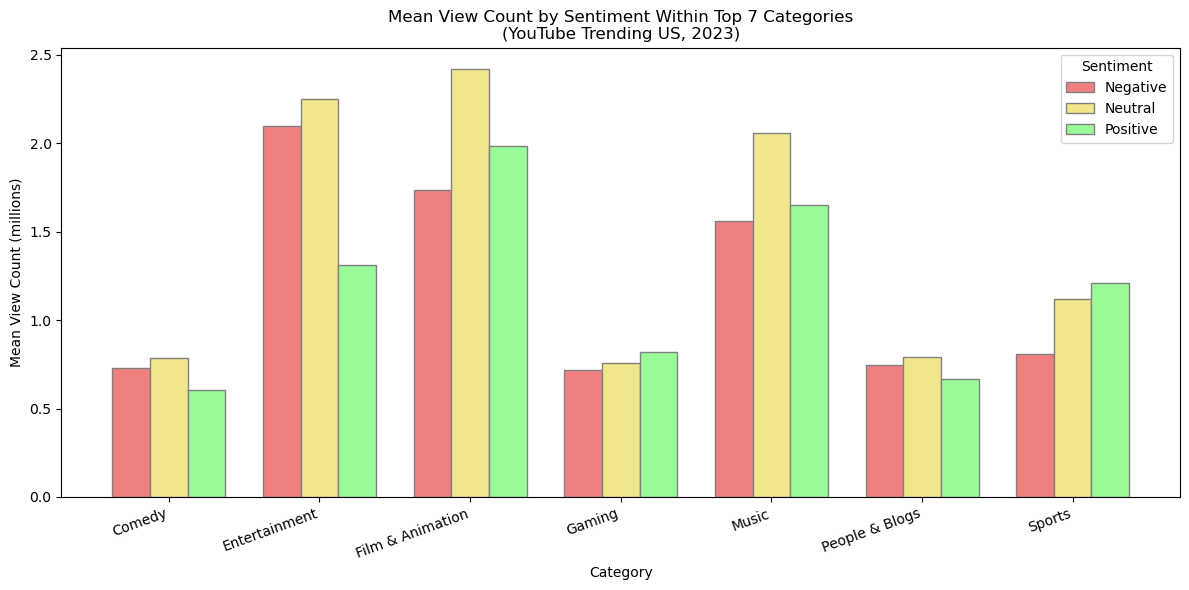

Caption: Mean view count (in millions) by content category and title sentiment label, for the 7 most common categories in the dataset. Neutral titles outperform within most categories, but the pattern is not universal -- suggesting that the overall neutral advantage is a consistent within-category effect rather than an artifact of category composition.


In [12]:
# select top 7 categories by video count for readability
top_cats = df['category'].value_counts().head(7).index.tolist()
df_top = df[df['category'].isin(top_cats)]

# mean view count (in millions) by category and sentiment
cat_sent_views = (
    df_top.groupby(['category', 'sentiment_label'])['view_count']
          .mean()
          .div(1_000_000)
          .unstack()[['negative', 'neutral', 'positive']]
)

sentiment_order = ['negative', 'neutral', 'positive']
x = np.arange(len(cat_sent_views))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, sentiment in enumerate(sentiment_order):
    ax.bar(
        x + (i - 1) * width,
        cat_sent_views[sentiment],
        width=width,
        color=SENTIMENT_COLORS[sentiment],
        label=sentiment.capitalize(),
        edgecolor='gray'
    )

ax.set_xticks(x)
ax.set_xticklabels(cat_sent_views.index, rotation=20, ha='right')
ax.set_xlabel('Category')
ax.set_ylabel('Mean View Count (millions)')
ax.set_title(
    'Mean View Count by Sentiment Within Top 7 Categories\n'
    '(YouTube Trending US, 2023)'
)
ax.legend(title='Sentiment')

save_fig(
    'fig9_views_by_category_sentiment.png',
    'Mean view count (in millions) by content category and title sentiment label, '
    'for the 7 most common categories in the dataset. '
    'Neutral titles outperform within most categories, but the pattern is not universal -- '
    'suggesting that the overall neutral advantage is a consistent within-category effect '
    'rather than an artifact of category composition.'
)

## Figure 10: Top 15 videos by days on trending

Days on trending is a secondary virality measure capturing sustained reach, as opposed to single-day view counts.

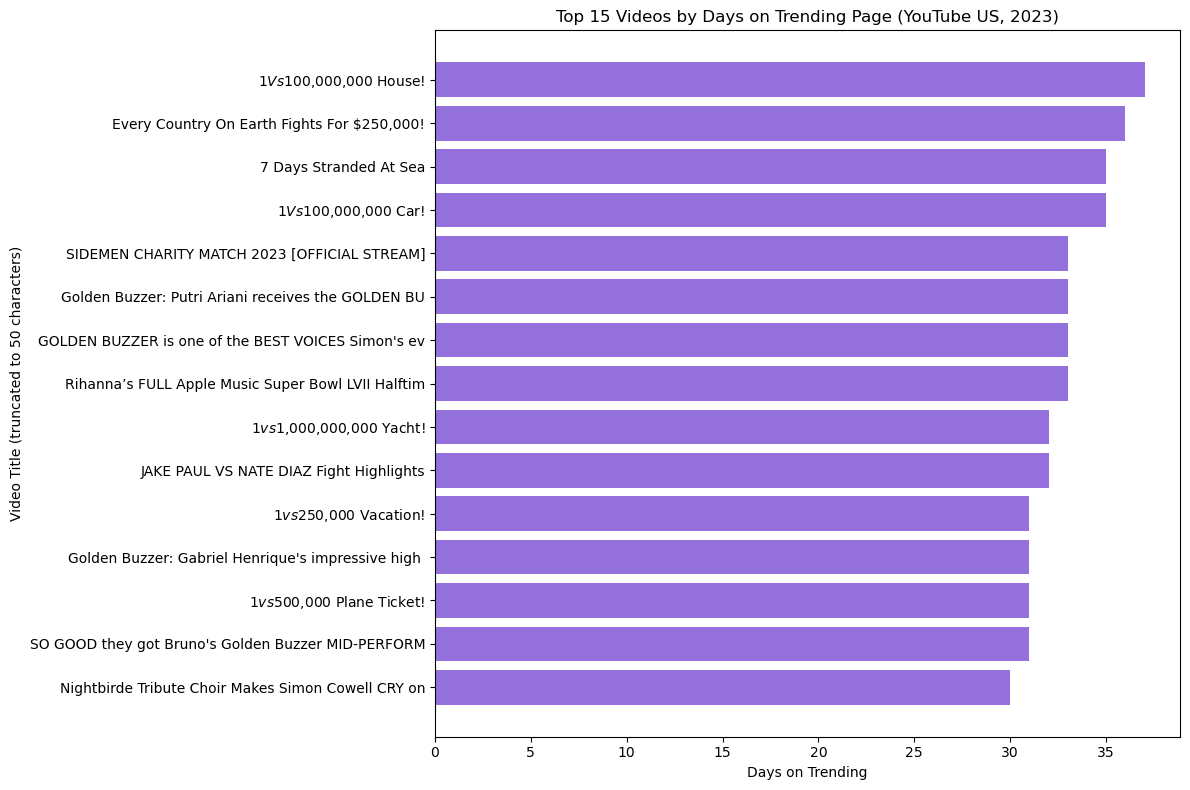

Caption: Top 15 YouTube trending videos ranked by total days on the trending page (US, 2023). Titles are truncated to 50 characters for readability. Days on trending is a secondary measure of sustained viral reach beyond single-day view accumulation.


In [13]:
top_trending = (
    df[['title', 'days_trending']]
      .sort_values('days_trending', ascending=True)
      .tail(15)
      .copy()
)
# truncate long titles so they fit on the axis
top_trending['title'] = top_trending['title'].str[:50]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top_trending['title'], top_trending['days_trending'], color='mediumpurple')

ax.set_xlabel('Days on Trending')
ax.set_ylabel('Video Title (truncated to 50 characters)')
ax.set_title('Top 15 Videos by Days on Trending Page (YouTube US, 2023)')

save_fig(
    'fig10_top_trending.png',
    'Top 15 YouTube trending videos ranked by total days on the trending page (US, 2023). '
    'Titles are truncated to 50 characters for readability. '
    'Days on trending is a secondary measure of sustained viral reach '
    'beyond single-day view accumulation.'
)